In [1]:
!pip install transformers datasets scikit-learn

import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import mean_squared_error, ndcg_score
import matplotlib.pyplot as plt


# 1. Setup paths and load data

BASE_PATH_1 = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project' # Contains CSVs and vocab
BASE_PATH_2 = '/kaggle/input/notebooks/srivarshitha16/gnn-pre-training' # Contains embeddings

# Load DataFrames
train_df = pd.read_csv(os.path.join(BASE_PATH_1, 'train_clean.csv'))
test_df = pd.read_csv(os.path.join(BASE_PATH_1, 'test_clean.csv'))

# Load Skill Graph Artifacts
with open(os.path.join(BASE_PATH_1, 'skill_vocab.json'), 'r') as f:
    skill_vocab = json.load(f)
skill_to_id = {skill: i for i, skill in enumerate(skill_vocab)}

# Load the embeddings you trained in Notebook 2!
pretrained_skill_embs = np.load(os.path.join(BASE_PATH_2, 'skill_embeddings.npy'))
pretrained_skill_embs = torch.tensor(pretrained_skill_embs, dtype=torch.float32)

print(f"Loaded Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Loaded Graph Embeddings: {pretrained_skill_embs.shape}")

# 2. Skill Extraction Function

import re
def extract_skill_ids(text, skill_dict, skill_map):
    """Finds skills in text and returns their Graph Node IDs"""
    if not isinstance(text, str): return []
    text_lower = text.lower()
    ids = []
    for skill in skill_dict:
        if re.search(r'\b' + re.escape(skill) + r'\b', text_lower):
            ids.append(skill_map[skill])
    return ids

# Let's extract skill IDs for all resumes and JDs so we don't have to do it during training
print("Extracting Skill IDs for training data...")
train_df['res_skill_ids'] = train_df['resume_text'].apply(lambda x: extract_skill_ids(x, skill_vocab, skill_to_id))
train_df['jd_skill_ids'] = train_df['job_description_text'].apply(lambda x: extract_skill_ids(x, skill_vocab, skill_to_id))

test_df['res_skill_ids'] = test_df['resume_text'].apply(lambda x: extract_skill_ids(x, skill_vocab, skill_to_id))
test_df['jd_skill_ids'] = test_df['job_description_text'].apply(lambda x: extract_skill_ids(x, skill_vocab, skill_to_id))

print(f"Sample Resume Skill IDs: {train_df['res_skill_ids'].iloc[0][:5]}...")

Loaded Train: 6241 | Test: 1759
Loaded Graph Embeddings: torch.Size([500, 128])
Extracting Skill IDs for training data...
Sample Resume Skill IDs: [13, 17, 18, 22, 24]...


In [2]:
class GraphEnhancedCrossEncoder(nn.Module):
    def __init__(self, transformer_name, pretrained_embeddings, freeze_transformer=False):
        super(GraphEnhancedCrossEncoder, self).__init__()
        
        # Branch 1: The Transformer (Semantic Text)
        self.transformer = AutoModel.from_pretrained(transformer_name)
        transformer_out_dim = self.transformer.config.hidden_size # Usually 384 or 768
        
        if freeze_transformer:
            for param in self.transformer.parameters():
                param.requires_grad = False
                
        # Branch 2: The Graph Embeddings (Hard Skills)
        # We load your pre-trained GAT weights into an embedding layer
        self.skill_embeddings = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        graph_out_dim = pretrained_embeddings.shape[1] # 128
        
        # Fusion Head: Concatenate Transformer + Resume Graph + JD Graph
        total_dim = transformer_out_dim + graph_out_dim + graph_out_dim
        
        self.mlp = nn.Sequential(
            nn.Linear(total_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid() # Outputs a score between 0.0 and 1.0
        )

    def forward(self, input_ids, attention_mask, res_skill_ids, jd_skill_ids):
        # 1. Run Text through Transformer
        transformer_outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        # Get the [CLS] token representation (the overall meaning of the text)
        cls_embedding = transformer_outputs.last_hidden_state[:, 0, :] 
        
        # 2. Get Graph Embeddings for Resume Skills
        batch_size = cls_embedding.size(0)
        res_graph_embs = []
        jd_graph_embs = []
        
        for i in range(batch_size):
            # If resume has skills, get their embeddings and average them (Mean Pooling)
            if len(res_skill_ids[i]) > 0:
                # Convert list to tensor and move to device
                r_ids = torch.tensor(res_skill_ids[i], dtype=torch.long, device=cls_embedding.device)
                r_embs = self.skill_embeddings(r_ids).mean(dim=0)
            else:
                # If no skills found, use a zero vector
                r_embs = torch.zeros(self.skill_embeddings.embedding_dim, device=cls_embedding.device)
            res_graph_embs.append(r_embs)
            
            # Do the same for JD skills
            if len(jd_skill_ids[i]) > 0:
                j_ids = torch.tensor(jd_skill_ids[i], dtype=torch.long, device=cls_embedding.device)
                j_embs = self.skill_embeddings(j_ids).mean(dim=0)
            else:
                j_embs = torch.zeros(self.skill_embeddings.embedding_dim, device=cls_embedding.device)
            jd_graph_embs.append(j_embs)
            
        res_graph_tensor = torch.stack(res_graph_embs)
        jd_graph_tensor = torch.stack(jd_graph_embs)
        
        # 3. Fuse Everything Together!
        fused_vector = torch.cat([cls_embedding, res_graph_tensor, jd_graph_tensor], dim=1)
        
        # 4. Predict Match Score
        score = self.mlp(fused_vector)
        return score.squeeze(-1)

print("Architecture successfully defined!")

Architecture successfully defined!


## Create Pytorch Dataset and Dataloader

In [3]:
# We use a small, fast model for prototyping (MiniLM is a great sentence-transformer)
MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResumeJDDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Text for Transformer (Cross-Encoder format: [CLS] Resume [SEP] JD [SEP])
        res_text = str(row['resume_text'])
        jd_text = str(row['job_description_text'])
        
        encoding = self.tokenizer(
            res_text,
            jd_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # 2. Graph Skill IDs
        res_skills = row['res_skill_ids']
        jd_skills = row['jd_skill_ids']
        
        # 3. Target Label (Score: 0.0, 0.5, or 1.0)
        target = torch.tensor(row['score'], dtype=torch.float)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'res_skill_ids': res_skills, # Keep as list for now, we process it in the model
            'jd_skill_ids': jd_skills,
            'target': target
        }

# Create DataLoaders
# Batch size of 16 is safe for MiniLM on a T4 GPU. If you get OutOfMemory (OOM), drop to 8.
train_dataset = ResumeJDDataset(train_df, tokenizer)
test_dataset = ResumeJDDataset(test_df, tokenizer)

# We use a custom collate_fn because our skill_ids are lists of different lengths
def custom_collate(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    targets = torch.stack([item['target'] for item in batch])
    
    # Keep skills as lists of lists
    res_skills = [item['res_skill_ids'] for item in batch]
    jd_skills = [item['jd_skill_ids'] for item in batch]
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'res_skill_ids': res_skills,
        'jd_skill_ids': jd_skills,
        'target': targets
    }

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=custom_collate)

print(f"Created Train Loader with {len(train_loader)} batches.")
print(f"Created Test Loader with {len(test_loader)} batches.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Created Train Loader with 391 batches.
Created Test Loader with 110 batches.


## Initialise model and the optimizer

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Initialize our Novel Architecture!
# We set freeze_transformer=False so the language model can adapt to resume jargon
model = GraphEnhancedCrossEncoder(
    transformer_name=MODEL_NAME, 
    pretrained_embeddings=pretrained_skill_embs,
    freeze_transformer=False
).to(device)

# 2. Setup Optimizer (AdamW is standard for Transformers)
# We use different learning rates: 
#   - Very small for the pre-trained Transformer
#   - Larger for the MLP head we are training from scratch
optimizer = torch.optim.AdamW([
    {'params': model.transformer.parameters(), 'lr': 2e-5},
    {'params': model.skill_embeddings.parameters(), 'lr': 1e-4},
    {'params': model.mlp.parameters(), 'lr': 1e-3}
])

# 3. Loss Function
# We use MSE (Mean Squared Error) because we formulated this as a regression problem (scores 0.0 to 1.0)
criterion = nn.MSELoss()

# Let's do a quick dry run of 1 batch to make sure shapes align and memory doesn't explode
print("Testing Forward Pass on 1 Batch...")
model.eval()
with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        res_skills = batch['res_skill_ids']
        jd_skills = batch['jd_skill_ids']
        
        scores = model(input_ids, attention_mask, res_skills, jd_skills)
        print(f"Success! Output batch shape: {scores.shape} (Expected: 16)")
        print(f"Sample Output Scores: {scores[:5].cpu().numpy()}")
        break # Just run one batch

Using device: cuda


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Testing Forward Pass on 1 Batch...
Success! Output batch shape: torch.Size([16]) (Expected: 16)
Sample Output Scores: [0.49385458 0.48912475 0.49248052 0.49179336 0.49073812]


## Multi-model Experiment framework

In [5]:
!pip install sentencepiece


 STARTING EXPERIMENT: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 [Train]:   0%|          | 0/781 [00:00<?, ?it/s]

--> Epoch 1 Test MAE: 0.3588


...

--> Epoch 1 Test MAE: nan


Epoch 2/3 [Train]:   0%|          | 0/781 [00:00<?, ?it/s]

--> Epoch 2 Test MAE: nan


Epoch 3/3 [Train]:   0%|          | 0/781 [00:00<?, ?it/s]

--> Epoch 3 Test MAE: nan
 Finished microsoft/deberta-v3-base. Final MAE: nan


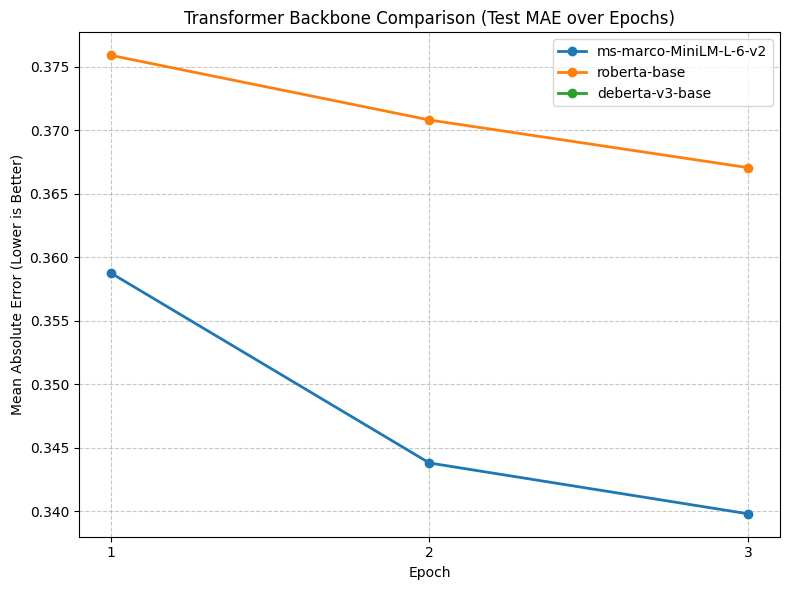

In [6]:
import gc
from tqdm.auto import tqdm

# We must reduce batch size to 8 because RoBERTa and DeBERTa are much larger than MiniLM
BATCH_SIZE = 8
EPOCHS = 3

# The models we want to compare 
MODELS_TO_TEST = [
    'cross-encoder/ms-marco-MiniLM-L-6-v2', # Baseline
    'roberta-base',                         # Industry Standard
    'microsoft/deberta-v3-base'             # State of the Art Semantic Matcher
]

# Dictionary to store results 
experiment_results = {}

def run_experiment(model_name):
    print(f"\n{'='*50}")
    print(f" STARTING EXPERIMENT: {model_name}")
    print(f"{'='*50}")
    
    # 1. Setup Tokenizer and DataLoaders specific to this model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # DeBERTa and RoBERTa handle token types differently, but HuggingFace handles most of it.
    train_dataset = ResumeJDDataset(train_df, tokenizer, max_length=512)
    test_dataset = ResumeJDDataset(test_df, tokenizer, max_length=512)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate)
    
    # 2. Initialize Model
    model = GraphEnhancedCrossEncoder(
        transformer_name=model_name, 
        pretrained_embeddings=pretrained_skill_embs,
        freeze_transformer=False
    ).to(device)
    
    # 3. Setup Optimizer & Loss
    optimizer = torch.optim.AdamW([
        {'params': model.transformer.parameters(), 'lr': 2e-5},
        {'params': model.skill_embeddings.parameters(), 'lr': 1e-4},
        {'params': model.mlp.parameters(), 'lr': 1e-3}
    ])
    criterion = nn.MSELoss()
    
    test_maes = [] # Track MAE for plotting
    
    # 4. Training Loop
    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for batch in progress_bar:
            optimizer.zero_grad()
            
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            
            # Forward Pass
            predictions = model(input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids'])
            
            # Loss & Backprop
            loss = criterion(predictions, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        # Evaluation Phase
        model.eval()
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                targets = batch['target'].to(device)
                
                predictions = model(input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids'])
                
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                
        # Calculate MAE
        mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
        test_maes.append(mae)
        print(f"--> Epoch {epoch+1} Test MAE: {mae:.4f}")
        
    print(f" Finished {model_name}. Final MAE: {test_maes[-1]:.4f}")
    
    # 5. VERY IMPORTANT: Free up GPU Memory so the next model doesn't crash Kaggle
    del model
    del optimizer
    del train_loader
    del test_loader
    gc.collect()
    torch.cuda.empty_cache()
    
    return test_maes

# Run the pipeline for all models!
for current_model in MODELS_TO_TEST:
    maes = run_experiment(current_model)
    # Save just the model name for cleaner plot legends
    clean_name = current_model.split('/')[-1] 
    experiment_results[clean_name] = maes


# 6. Plot the results for the README

plt.figure(figsize=(8, 6))
for model_name, maes in experiment_results.items():
    plt.plot(range(1, EPOCHS + 1), maes, marker='o', linewidth=2, label=model_name)

plt.title("Transformer Backbone Comparison (Test MAE over Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

DeBERTa usually is very unstable when the learning rate is high like in the above case, we can shelf it for now.
In other cases as well the MAE needs to be pushed down.

## Training Loop

In [7]:
from tqdm.auto import tqdm

epochs = 3
best_test_loss = float('inf')

print("Starting Late Fusion Training...")
train_losses = []
test_losses = []

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    
    # We use tqdm for a nice progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for batch in progress_bar:
        optimizer.zero_grad()
        
        # Move tensors to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'].to(device)
        res_skills = batch['res_skill_ids']
        jd_skills = batch['jd_skill_ids']
        
        # Forward Pass
        predictions = model(input_ids, attention_mask, res_skills, jd_skills)
        
        # Calculate Loss
        loss = criterion(predictions, targets)
        
        # Backward Pass
        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_train_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- EVALUATION PHASE ---
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            res_skills = batch['res_skill_ids']
            jd_skills = batch['jd_skill_ids']
            
            predictions = model(input_ids, attention_mask, res_skills, jd_skills)
            loss = criterion(predictions, targets)
            
            total_test_loss += loss.item()
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Calculate Mean Absolute Error (MAE) for easier human understanding
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss (MSE): {avg_train_loss:.4f} | Test Loss (MSE): {avg_test_loss:.4f}")
    print(f"Test MAE: {mae:.4f} (Average error of {mae*100:.1f}%)")
    
    # Save best model
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), '/kaggle/working/best_fusion_model.pth')
        print("--> Saved new best model!")

Starting Late Fusion Training...


Epoch 1/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/3 [Test]:   0%|          | 0/110 [00:00<?, ?it/s]


Epoch 1 Summary:
Train Loss (MSE): 0.1564 | Test Loss (MSE): 0.1827
Test MAE: 0.3669 (Average error of 36.7%)
--> Saved new best model!


Epoch 2/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/3 [Test]:   0%|          | 0/110 [00:00<?, ?it/s]


Epoch 2 Summary:
Train Loss (MSE): 0.1250 | Test Loss (MSE): 0.1846
Test MAE: 0.3583 (Average error of 35.8%)


Epoch 3/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 3/3 [Test]:   0%|          | 0/110 [00:00<?, ?it/s]


Epoch 3 Summary:
Train Loss (MSE): 0.1089 | Test Loss (MSE): 0.1802
Test MAE: 0.3558 (Average error of 35.6%)
--> Saved new best model!


## Define MoE Architecture

In [8]:
import torch.nn.functional as F

class MoE_GraphCrossEncoder(nn.Module):
    def __init__(self, transformer_name, pretrained_embeddings, freeze_transformer=False):
        super(MoE_GraphCrossEncoder, self).__init__()
        
        # 1. The Backbone (Text)
        self.transformer = AutoModel.from_pretrained(transformer_name)
        transformer_out_dim = self.transformer.config.hidden_size # e.g., 384 for MiniLM
        if freeze_transformer:
            for param in self.transformer.parameters():
                param.requires_grad = False
                
        # 2. The Backbone (Graph)
        self.skill_embeddings = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        graph_out_dim = pretrained_embeddings.shape[1] # e.g., 128
        
        # Mixture of experts (MoE) layers
        
        # EXPERT 1: Semantic Text Expert
        self.text_expert = nn.Sequential(
            nn.Linear(transformer_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid() # Outputs a score between 0 and 1
        )
        
        # EXPERT 2: Hard Skills (Graph) Expert
        # Takes Resume Graph (128) + JD Graph (128) = 256
        self.graph_expert = nn.Sequential(
            nn.Linear(graph_out_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
        #  Gating Network
        # Takes everything (384 + 128 + 128 = 640) and outputs 2 weights
        self.gating_network = nn.Sequential(
            nn.Linear(transformer_out_dim + (graph_out_dim * 2), 128),
            nn.ReLU(),
            nn.Linear(128, 2), # 2 outputs: Weight for Text, Weight for Graph
            nn.Softmax(dim=1)  # Ensures the two weights sum to exactly 1.0 (e.g., 0.7 and 0.3)
        )

    def forward(self, input_ids, attention_mask, res_skill_ids, jd_skill_ids):
        # 1. Get Text Embedding
        transformer_outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = transformer_outputs.last_hidden_state[:, 0, :] 
        
        # 2. Get Graph Embeddings (Mean Pooling)
        batch_size = cls_embedding.size(0)
        res_graph_embs, jd_graph_embs = [], []
        
        for i in range(batch_size):
            # Resume Skills
            if len(res_skill_ids[i]) > 0:
                r_ids = torch.tensor(res_skill_ids[i], dtype=torch.long, device=cls_embedding.device)
                r_embs = self.skill_embeddings(r_ids).mean(dim=0)
            else:
                r_embs = torch.zeros(self.skill_embeddings.embedding_dim, device=cls_embedding.device)
            res_graph_embs.append(r_embs)
            
            # JD Skills
            if len(jd_skill_ids[i]) > 0:
                j_ids = torch.tensor(jd_skill_ids[i], dtype=torch.long, device=cls_embedding.device)
                j_embs = self.skill_embeddings(j_ids).mean(dim=0)
            else:
                j_embs = torch.zeros(self.skill_embeddings.embedding_dim, device=cls_embedding.device)
            jd_graph_embs.append(j_embs)
            
        res_graph_tensor = torch.stack(res_graph_embs)
        jd_graph_tensor = torch.stack(jd_graph_embs)
        
        
        # MoE ROUTING AND SCORING
        
        
        # A. Ask the Experts for their opinions (Scores from 0 to 1)
        text_score = self.text_expert(cls_embedding)
        graph_score = self.graph_expert(torch.cat([res_graph_tensor, jd_graph_tensor], dim=1))
        
        # B. Ask the Gating Network who to trust
        fused_context = torch.cat([cls_embedding, res_graph_tensor, jd_graph_tensor], dim=1)
        gate_weights = self.gating_network(fused_context) # Shape: [Batch, 2]
        
        weight_text = gate_weights[:, 0].unsqueeze(1)
        weight_graph = gate_weights[:, 1].unsqueeze(1)
        
        # C. Calculate Final Weighted Score
        final_score = (weight_text * text_score) + (weight_graph * graph_score)
        
        # We return the final score, but also the internal thoughts for our Recourse Analysis!
        return final_score.squeeze(-1), gate_weights, text_score.squeeze(-1), graph_score.squeeze(-1)

print(" MoE Architecture successfully defined!")

 MoE Architecture successfully defined!


## Training MoE

In [9]:
# Initialize MoE Model
moe_model = MoE_GraphCrossEncoder(
    transformer_name='cross-encoder/ms-marco-MiniLM-L-6-v2', 
    pretrained_embeddings=pretrained_skill_embs,
    freeze_transformer=False
).to(device)

# Optimizer
optimizer_moe = torch.optim.AdamW([
    {'params': moe_model.transformer.parameters(), 'lr': 2e-5},
    {'params': moe_model.skill_embeddings.parameters(), 'lr': 1e-4},
    {'params': moe_model.text_expert.parameters(), 'lr': 1e-3},
    {'params': moe_model.graph_expert.parameters(), 'lr': 1e-3},
    {'params': moe_model.gating_network.parameters(), 'lr': 1e-3}
])

criterion = nn.MSELoss()
EPOCHS = 3

print(" Starting MoE Training...")
moe_test_maes = []

for epoch in range(EPOCHS):
    moe_model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in progress_bar:
        optimizer_moe.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'].to(device)
        
        # Notice we only use the final_score for the loss
        final_score, gate_weights, text_score, graph_score = moe_model(
            input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids']
        )
        
        loss = criterion(final_score, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(moe_model.parameters(), max_norm=1.0)
        optimizer_moe.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    # --- EVALUATION ---
    moe_model.eval()
    all_preds, all_targets = [], []
    
    # We will save one batch of outputs to look at the "Interpretability" later
    sample_gate_weights, sample_text_scores, sample_graph_scores = None, None, None
    
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            
            final_score, gate_weights, text_score, graph_score = moe_model(
                input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids']
            )
            
            all_preds.extend(final_score.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            # Save the very first batch for our interpretability printout
            if i == 0:
                sample_gate_weights = gate_weights.cpu().numpy()
                sample_text_scores = text_score.cpu().numpy()
                sample_graph_scores = graph_score.cpu().numpy()
                sample_final_scores = final_score.cpu().numpy()
                sample_targets = targets.cpu().numpy()
                
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
    moe_test_maes.append(mae)
    print(f"--> Epoch {epoch+1} Test MAE: {mae:.4f}")



print("\n" + "-"*20)
print(" INSIDE THE MoE's BRAIN (Interpretability Sample)")
print("-"*20)

for i in range(3): # Look at 3 random candidates from our test sample
    print(f"\nCandidate {i+1}:")
    print(f"  True Label (HR Decision):   {sample_targets[i]:.2f}")
    print(f"  Final MoE Predicted Score:  {sample_final_scores[i]:.2f}")
    print("-" * 40)
    print(f"   Text Expert Score:       {sample_text_scores[i]:.2f}")
    print(f"   Graph Expert Score:      {sample_graph_scores[i]:.2f}")
    print(f"   Gating Network Decision: Trusted Text {sample_gate_weights[i][0]*100:.1f}% | Trusted Graph {sample_gate_weights[i][1]*100:.1f}%")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Starting MoE Training...


Epoch 1/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 1 Test MAE: 0.3679


Epoch 2/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 2 Test MAE: 0.3492


Epoch 3/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 3 Test MAE: 0.3498

--------------------
 INSIDE THE MoE's BRAIN (Interpretability Sample)
--------------------

Candidate 1:
  True Label (HR Decision):   0.00
  Final MoE Predicted Score:  0.23
----------------------------------------
   Text Expert Score:       0.09
   Graph Expert Score:      0.45
   Gating Network Decision: Trusted Text 59.9% | Trusted Graph 40.1%

Candidate 2:
  True Label (HR Decision):   0.00
  Final MoE Predicted Score:  0.14
----------------------------------------
   Text Expert Score:       0.02
   Graph Expert Score:      0.46
   Gating Network Decision: Trusted Text 73.4% | Trusted Graph 26.6%

Candidate 3:
  True Label (HR Decision):   0.00
  Final MoE Predicted Score:  0.07
----------------------------------------
   Text Expert Score:       0.00
   Graph Expert Score:      0.47
   Gating Network Decision: Trusted Text 85.2% | Trusted Graph 14.8%


## Save MoE

In [10]:
import torch

# Save the trained Mixture-of-Experts model
torch.save(moe_model.state_dict(), '/kaggle/working/best_moe_model.pth')
print(" MoE Model weights saved successfully to /kaggle/working/best_moe_model.pth")

 MoE Model weights saved successfully to /kaggle/working/best_moe_model.pth


## Cross-Attention architecture

In [11]:
class CrossAttention_GraphEncoder(nn.Module):
    def __init__(self, transformer_name, pretrained_embeddings, freeze_transformer=False):
        super(CrossAttention_GraphEncoder, self).__init__()
        
        # 1. Text Backbone
        self.transformer = AutoModel.from_pretrained(transformer_name)
        self.d_text = self.transformer.config.hidden_size # 384 for MiniLM
        
        if freeze_transformer:
            for param in self.transformer.parameters():
                param.requires_grad = False
                
        # 2. Graph Backbone
        self.skill_embeddings = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.d_graph = pretrained_embeddings.shape[1] # 128
        
        # 3. Projection Layer (Match Graph dimension to Text dimension)
        # We need the Graph to be 384-dim so it can interact with the 384-dim Text
        self.graph_projector = nn.Linear(self.d_graph, self.d_text)
        
        # 4. CROSS-ATTENTION LAYER
        # Text will be the Query. Graph will be the Key & Value.
        self.cross_attention = nn.MultiheadAttention(embed_dim=self.d_text, num_heads=4, batch_first=True)
        
        # 5. Final Scoring MLP
        # Takes the original [CLS] text token + the new Attention-enriched graph vector
        self.mlp = nn.Sequential(
            nn.Linear(self.d_text * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask, res_skill_ids, jd_skill_ids):
        # 1. Get Text Embeddings (Sequence of all words, not just CLS)
        transformer_outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        # Shape: [Batch, Sequence_Length (512), 384]
        text_sequence = transformer_outputs.last_hidden_state 
        cls_token = text_sequence[:, 0, :] # Save CLS for later
        
        # 2. Get Graph Embeddings as a Sequence
        batch_size = text_sequence.size(0)
        combined_graph_seqs = []
        
        for i in range(batch_size):
            # Combine Resume and JD skills into one pool of "Knowledge" for this batch
            all_ids = res_skill_ids[i] + jd_skill_ids[i]
            
            if len(all_ids) > 0:
                ids_tensor = torch.tensor(all_ids, dtype=torch.long, device=text_sequence.device)
                # Shape: [Num_Skills, 128]
                embs = self.skill_embeddings(ids_tensor) 
            else:
                # Dummy token if no skills found
                embs = torch.zeros((1, self.d_graph), device=text_sequence.device)
                
            combined_graph_seqs.append(embs)
            
        # 3. Pad the graph sequences so we can batch them (since each row has different # of skills)
        from torch.nn.utils.rnn import pad_sequence
        # Shape: [Batch, Max_Skills_In_Batch, 128]
        padded_graph = pad_sequence(combined_graph_seqs, batch_first=True) 
        
        # Project Graph to 384-dim
        # Shape: [Batch, Max_Skills, 384]
        projected_graph = self.graph_projector(padded_graph)
        
        # 4. CROSS-ATTENTION 
        # Query = Text Sequence, Key/Value = Graph Sequence
        # The text "asks" the graph for relevant skill context
        attn_output, attn_weights = self.cross_attention(
            query=text_sequence, 
            key=projected_graph, 
            value=projected_graph
        )
        
        # We take the [CLS] position of the attention output as the "Summarized Enriched Context"
        enriched_context = attn_output[:, 0, :]
        
        # 5. Final Score
        fused_vector = torch.cat([cls_token, enriched_context], dim=1)
        score = self.mlp(fused_vector)
        
        return score.squeeze(-1)

print(" Cross-Attention Architecture successfully defined!")

 Cross-Attention Architecture successfully defined!


## Training

In [12]:
# Initialize Cross-Attention Model
ca_model = CrossAttention_GraphEncoder(
    transformer_name='cross-encoder/ms-marco-MiniLM-L-6-v2', 
    pretrained_embeddings=pretrained_skill_embs,
    freeze_transformer=False
).to(device)

# Optimizer
optimizer_ca = torch.optim.AdamW([
    {'params': ca_model.transformer.parameters(), 'lr': 2e-5},
    {'params': ca_model.skill_embeddings.parameters(), 'lr': 1e-4},
    {'params': ca_model.graph_projector.parameters(), 'lr': 1e-3},
    {'params': ca_model.cross_attention.parameters(), 'lr': 1e-4},
    {'params': ca_model.mlp.parameters(), 'lr': 1e-3}
])

criterion = nn.MSELoss()

print(" Starting Cross-Attention Training...")
ca_test_maes = []

for epoch in range(3):
    ca_model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/3 [Train]")
    for batch in progress_bar:
        optimizer_ca.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'].to(device)
        
        predictions = ca_model(input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids'])
        
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ca_model.parameters(), max_norm=1.0)
        optimizer_ca.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    # --- EVALUATION ---
    ca_model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            
            predictions = ca_model(input_ids, attention_mask, batch['res_skill_ids'], batch['jd_skill_ids'])
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
    ca_test_maes.append(mae)
    print(f"--> Epoch {epoch+1} Test MAE: {mae:.4f}")

# Save it!
torch.save(ca_model.state_dict(), '/kaggle/working/best_crossattn_model.pth')
print(" Cross-Attention Model weights saved successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Starting Cross-Attention Training...


Epoch 1/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 1 Test MAE: 0.3496


Epoch 2/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 2 Test MAE: 0.3480


Epoch 3/3 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

--> Epoch 3 Test MAE: 0.3419
 Cross-Attention Model weights saved successfully!
